# Exact Diagonalization of the 2D Heisenberg Model

This notebook uses `QuSpin` to investigate the low-energy spectrum and magnetization of the spin-1/2 Heisenberg model on a square lattice with periodic boundary conditions (PBC). The Hamiltonian is given by:

$$\mathcal{H} = J \sum_{\langle i,j \rangle} \vec{S}_i \cdot \vec{S}_j + H \sum_{i} S_i^z$$

We exploit the total magnetization symmetry ($[ \mathcal{H}, S^z_{\text{total}} ] = 0$) to block-diagonalize the Hamiltonian, allowing us to compute the energy spectrum and the average magnetization $\langle M_z \rangle$ as a function of the external field $H/J$.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from quspin.basis import spin_basis_1d
from quspin.operators import hamiltonian
from tqdm.notebook import tqdm # Use notebook version for cleaner progress bars

def get_bonds_pbc(Lx, Ly):
    """Generate nearest-neighbor bonds for a 2D square lattice with PBC."""
    bonds = set()
    for x in range(Lx):
        for y in range(Ly):
            i = x + y * Lx
            
            # Right neighbor
            x_right = (x + 1) % Lx
            i_right = x_right + y * Lx
            if i != i_right:
                bonds.add(tuple(sorted((i, i_right))))
                
            # Top neighbor
            y_top = (y + 1) % Ly
            i_top = x + y_top * Lx
            if i != i_top:
                bonds.add(tuple(sorted((i, i_top))))
                
    return list(bonds)

def get_candidate_states(Lx, Ly, J_val, max_states_per_sector=None):
    """
    Finds the zero-field Heisenberg energies and Sz for the eigenstates.
    Returns a numpy array of pairs: (Sz_total, E_heis), sorted by E_heis.
    """
    N = Lx * Ly
    bonds = get_bonds_pbc(Lx, Ly)
    J_list = [[J_val, i, j] for i, j in bonds]
    static_heis = [["xx", J_list], ["yy", J_list], ["zz", J_list]]
    candidates = []
    
    for Nup in tqdm(range(N + 1), desc=f"Diagonalizing {Lx}x{Ly} (N={N})"):
        # Explicitly use pauli=0 to use Spin-1/2 operators instead of Pauli matrices
        basis = spin_basis_1d(L=N, Nup=Nup, pauli=0)
        if basis.Ns == 0: continue
            
        H_heis = hamiltonian(static_heis, [], basis=basis, dtype=np.float64, 
                             check_herm=False, check_pcon=False)
        
        if max_states_per_sector is None or basis.Ns <= max_states_per_sector + 2:
            E_sector = H_heis.eigvalsh()
            if max_states_per_sector is not None:
                E_sector = E_sector[:max_states_per_sector]
        else:
            try:
                E_sector = H_heis.eigsh(k=max_states_per_sector, which="SA", return_eigenvectors=False)
            except:
                E_sector = H_heis.eigvalsh()[:max_states_per_sector]
                
        Sz_total = Nup - (N / 2.0)
        for E in E_sector:
            candidates.append((Sz_total, E))
            
    candidates_array = np.array(candidates)
    sorted_indices = np.argsort(candidates_array[:, 1])
    return candidates_array[sorted_indices]

# Global parameters for the simulation
J = 1.0
H_vals = np.linspace(0, 10, 2000) # Sweep H/J from 0 to 10

## 1. The 2x2 Lattice ($N=4$)
Because the $2 \times 2$ lattice with PBC simplifies to a 1D ring of 4 sites (each site has a coordination number $z=2$), the physics is very simple. We will plot the full 16-state spectrum and the resulting magnetization curve.

Diagonalizing 2x2 (N=4):   0%|          | 0/5 [00:00<?, ?it/s]

Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!


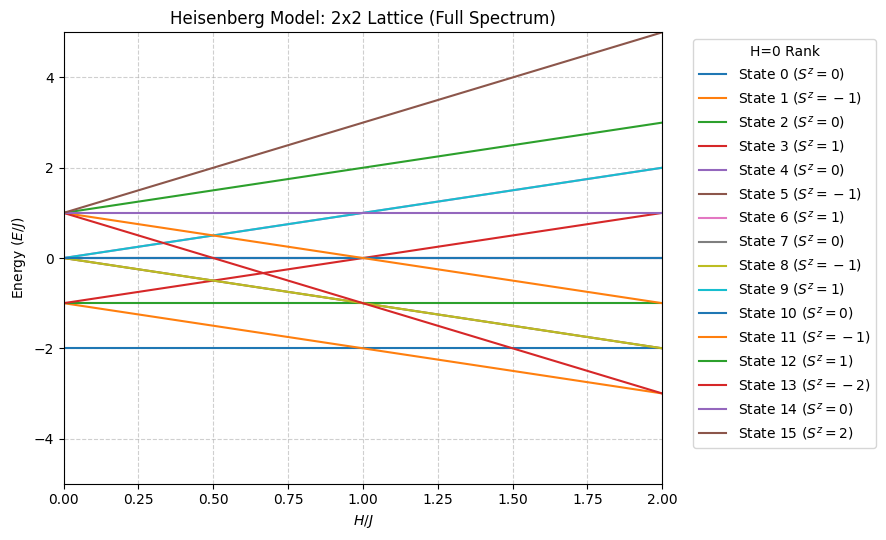

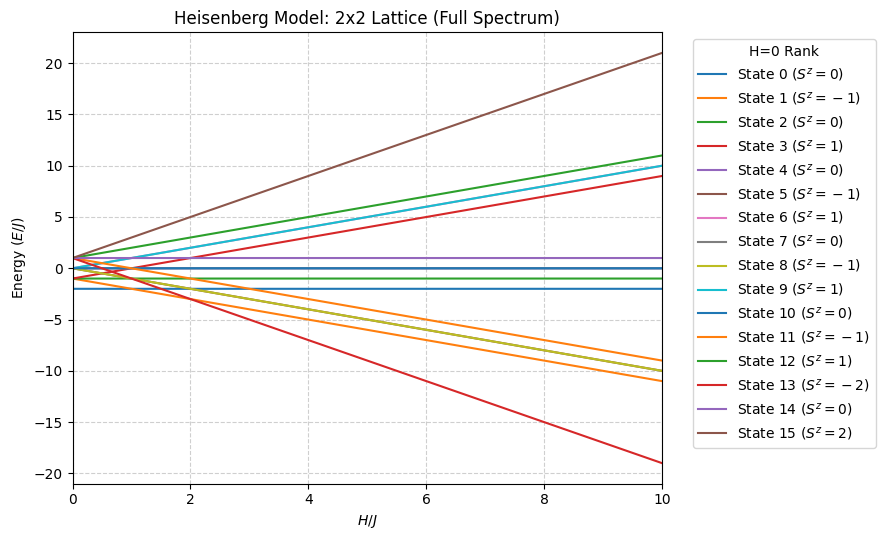

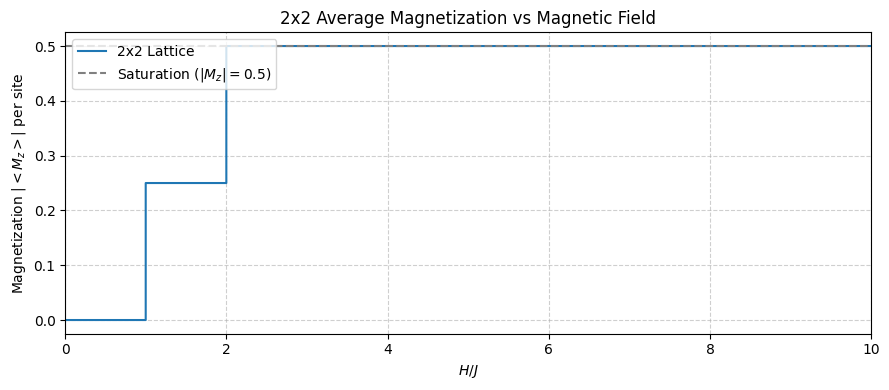

In [14]:
# --- Calculate 2x2 Data ---
candidates_2x2 = get_candidate_states(2, 2, J, max_states_per_sector=None)

Sz_2x2 = candidates_2x2[:, 0][:, np.newaxis]
E_heis_2x2 = candidates_2x2[:, 1][:, np.newaxis]

# Calculate total energy: E = E_heis + H * Sz
energies_2x2 = E_heis_2x2 + H_vals * Sz_2x2 

# Magnetization logic
gs_indices_2x2 = np.argmin(energies_2x2, axis=0)
gs_Sz_2x2 = Sz_2x2[gs_indices_2x2, 0]
Mz_2x2 = np.abs(gs_Sz_2x2 / 4.0)

# --- Plot 2x2 Spectrum ---
plt.figure(figsize=(9, 5.5))
for i in range(energies_2x2.shape[0]):
    sz_val = int(Sz_2x2[i, 0])
    plt.plot(H_vals / J, energies_2x2[i] / J, label=f'State {i} ($S^z={sz_val}$)')
    
plt.title('Heisenberg Model: 2x2 Lattice (Full Spectrum)')
plt.xlabel('$H/J$')
plt.ylabel('Energy ($E/J$)')
plt.xlim(0, 2)
plt.ylim(-5, 5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", title="H=0 Rank")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5.5))
for i in range(energies_2x2.shape[0]):
    sz_val = int(Sz_2x2[i, 0])
    plt.plot(H_vals / J, energies_2x2[i] / J, label=f'State {i} ($S^z={sz_val}$)')
    
plt.title('Heisenberg Model: 2x2 Lattice (Full Spectrum)')
plt.xlabel('$H/J$')
plt.ylabel('Energy ($E/J$)')
plt.xlim(0, 10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", title="H=0 Rank")
plt.tight_layout()
plt.show()

# --- Plot 2x2 Magnetization ---
plt.figure(figsize=(9, 4))
plt.plot(H_vals / J, Mz_2x2, label='2x2 Lattice', color='C0', drawstyle='steps-mid')
plt.title('2x2 Average Magnetization vs Magnetic Field')
plt.xlabel('$H/J$')
plt.ylabel('Magnetization $|< M_z >|$ per site')
plt.axhline(0.5, color='gray', linestyle='--', label='Saturation ($|M_z| = 0.5$)')
plt.xlim(0, 10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 2. The 4x4 Lattice ($N=16$)
The $4 \times 4$ lattice has a true 2D topology with a coordination number $z=4$. We will plot the lowest energy states per sector, the lowest 6 energy levels (at any given H/J between 0 and 10), and the magnetization per site. Due to the higher $z$, saturation requires a stronger magnetic field.

In [16]:
# --- Calculate 4x4 Data ---
# 1. Get ONLY the lowest state for each Sz sector
candidates_4x4_sec = get_candidate_states(4, 4, J, max_states_per_sector=1)
Sz_4x4_sec = candidates_4x4_sec[:, 0][:, np.newaxis]
E_heis_4x4_sec = candidates_4x4_sec[:, 1][:, np.newaxis]
energies_4x4_sec = E_heis_4x4_sec + H_vals * Sz_4x4_sec

# Magnetization logic
gs_indices_4x4 = np.argmin(energies_4x4_sec, axis=0)
gs_Sz_4x4 = Sz_4x4_sec[gs_indices_4x4, 0]
Mz_4x4 = np.abs(gs_Sz_4x4 / 16.0)

# 2. Get the full spectrum to find the true lowest 6 levels over time
candidates_4x4_all = get_candidate_states(4, 4, J, max_states_per_sector=None)
Sz_4x4_all = candidates_4x4_all[:, 0][:, np.newaxis]
E_heis_4x4_all = candidates_4x4_all[:, 1][:, np.newaxis]
energies_4x4_all = E_heis_4x4_all + H_vals * Sz_4x4_all
lowest_6_at_each_H = np.sort(energies_4x4_all, axis=0)[:6, :]

Diagonalizing 4x4 (N=16):   0%|          | 0/17 [00:00<?, ?it/s]

Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!


Diagonalizing 4x4 (N=16):   0%|          | 0/17 [00:00<?, ?it/s]

Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!


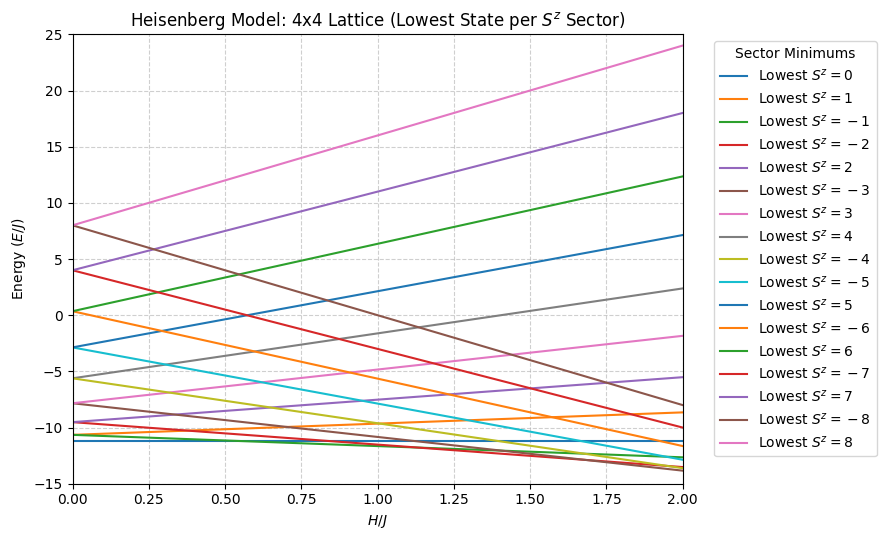

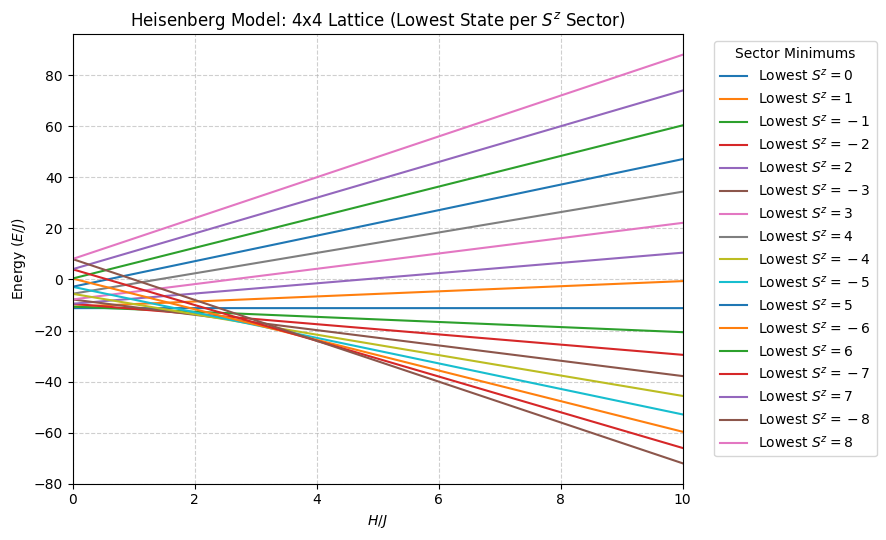

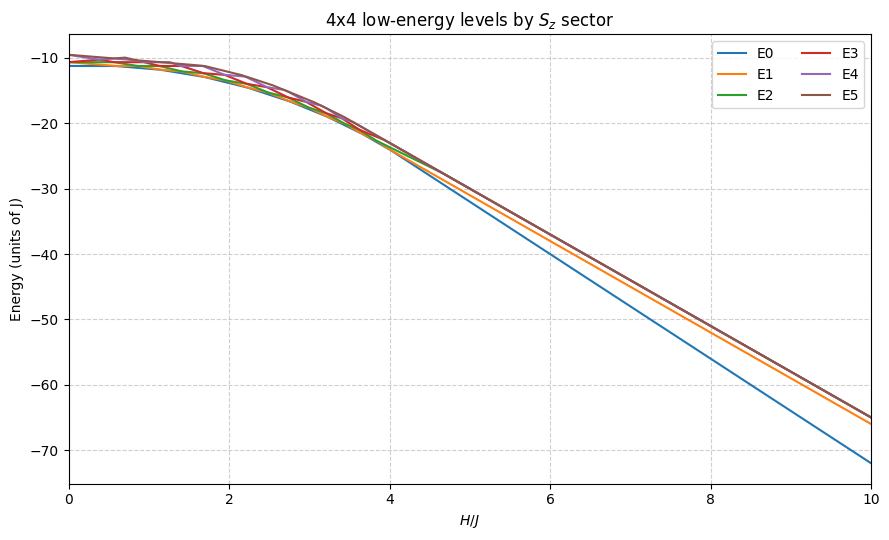

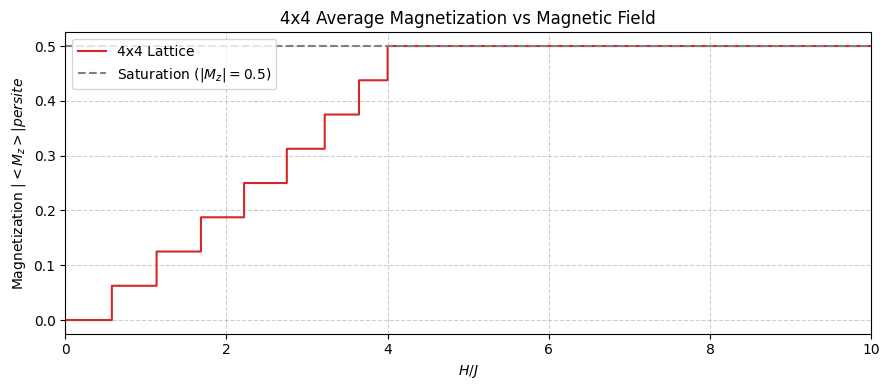

In [20]:
# --- Plot 4x4 Sector Minimums but zoomed in ---
plt.figure(figsize=(9, 5.5))
for i in range(energies_4x4_sec.shape[0]):
    sz_val = int(Sz_4x4_sec[i, 0])
    plt.plot(H_vals / J, energies_4x4_sec[i] / J, label=f'Lowest $S^z={sz_val}$')
plt.title('Heisenberg Model: 4x4 Lattice (Lowest State per $S^z$ Sector)')
plt.xlabel('$H/J$')
plt.ylabel('Energy ($E/J$)')
plt.xlim(0, 2)
plt.ylim(-15, 25)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", title="Sector Minimums")
plt.tight_layout()
plt.show()

# --- Plot 4x4 Sector Minimums ---
plt.figure(figsize=(9, 5.5))
for i in range(energies_4x4_sec.shape[0]):
    sz_val = int(Sz_4x4_sec[i, 0])
    plt.plot(H_vals / J, energies_4x4_sec[i] / J, label=f'Lowest $S^z={sz_val}$')
plt.title('Heisenberg Model: 4x4 Lattice (Lowest State per $S^z$ Sector)')
plt.xlabel('$H/J$')
plt.ylabel('Energy ($E/J$)')
plt.xlim(0, 10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", title="Sector Minimums")
plt.tight_layout()
plt.show()

# --- Plot 4x4 Lowest 6 Levels ---
plt.figure(figsize=(9, 5.5))
for i in range(6):
    plt.plot(H_vals / J, lowest_6_at_each_H[i] / J, label=f'E{i}')
plt.title('4x4 low-energy levels by $S_z$ sector')
plt.xlabel('$H/J$')
plt.ylabel('Energy (units of J)')
plt.xlim(0, 10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', ncol=2)
plt.tight_layout()
plt.show()

# --- Plot 4x4 Magnetization ---
plt.figure(figsize=(9, 4))
plt.plot(H_vals / J, Mz_4x4, label='4x4 Lattice', color='C3', drawstyle='steps-mid')
plt.title('4x4 Average Magnetization vs Magnetic Field')
plt.xlabel('$H/J$')
plt.ylabel('Magnetization $|< M_z >| per site$')
plt.axhline(0.5, color='gray', linestyle='--', label='Saturation ($|M_z| = 0.5$)')
plt.xlim(0, 10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 3. Resource Estimation for a 6x6 Lattice ($N=36$)
Moving from $N=16$ to $N=36$ causes the Hilbert space to grow exponentially, moving the problem out of the realm of exact diagonalization (ED) on standard hardware.

**1. The Full Hamiltonian:**
The total number of states is $2^{36} \approx 6.87 \times 10^{10}$ (68.7 billion states). 
Algorithms like Lanczos iteration require storing several state vectors in RAM simultaneously. To store a single double-precision vector (8 bytes per entry) of this size:
* $\text{Memory per vector} = 6.87 \times 10^{10} \times 8 \text{ bytes} \approx \textbf{550 GB}$
Because Lanczos typically requires at least 3-4 vectors in memory at once, diagonalizing the full space would require upwards of **1.5 to 2.2 Terabytes of RAM**.

**2. The $S^z_{\text{total}} = 0$ Symmetry Sector:**
If we restrict our calculation to the largest non-interacting block ($N_{\uparrow} = 18$), the matrix dimension becomes $\binom{36}{18} = 9,075,135,300$.
* $\text{Memory per vector} = 9.07 \times 10^9 \times 8 \text{ bytes} \approx \textbf{72.6 GB}$
Running Lanczos on just this sector requires roughly **220 GB of RAM**. While feasible on a high-performance computing cluster, it is completely inaccessible for a personal laptop or standard desktop.

---

## 4. The Thermodynamic Limit ($N \to \infty$)

### The Phase Transition
In our finite-size models, the transition from an Antiferromagnetic (AFM) ground state to a fully polarized Ferromagnetic (FM) state occurs via discrete, macroscopic level crossings. This manifests as a staircase in the magnetization plots. 

As the system size scales to the thermodynamic limit ($N \to \infty$), the height of each magnetization step ($\Delta M_z = 1/N$) approaches zero. The discrete staircase smooths out into a continuous curve. The system undergoes a **continuous quantum phase transition** at zero temperature. The magnetization $\langle M_z \rangle$ increases smoothly as the field bends the spins, but its derivative (the magnetic susceptibility $\chi$) drops abruptly to zero the moment the system reaches saturation. 

### Assigning the Critical Field $(H/J)_c$
We can derive the exact critical field $(H/J)_c$ in the thermodynamic limit by analyzing the **single-magnon excitation gap**. 

Assume the system is already fully polarized (all spins pointing down). If we create exactly one elementary excitation (a magnon) by flipping a single spin against the magnetic field, there is a competition of energies:
1. We *cost* energy from the external magnetic field $H$.
2. We *gain* energy from the antiferromagnetic Heisenberg interaction $J$ with the neighboring spins.

The energy cost to create this single magnon with momentum $\vec{k}$ is given by the exact dispersion relation:
$$\Delta E(\vec{k}) = H - z J S (1 - \gamma_{\vec{k}})$$
where $z$ is the lattice coordination number and $\gamma_{\vec{k}}$ is the structure factor of the lattice. 

For a 2D square lattice, the minimum of this gap (the lowest energy magnon) occurs at the Brillouin zone corner $\vec{k} = (\pi, \pi)$, where $\gamma_{\vec{k}} = -1$.
$$\Delta E_{min} = H - 2zJS$$

The transition occurs exactly when this gap closes ($\Delta E_{min} = 0$), meaning the magnetic field is no longer strong enough to suppress the creation of magnons. 
$$H_c = 2zJS$$

For our specific setup—a 2D square lattice ($z=4$) with spin-1/2 particles ($S=1/2$)—we find:
$$H_c = 2(4)J(1/2) = \textbf{4J}$$

Therefore, the critical value is exactly **$(H/J)_c = 4$**. This macroscopic limit is beautifully visible in our finite $4 \times 4$ exact diagonalization, which hits its final saturation plateau at exactly $H/J = 4$.